In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

# 1. 함수 형태에 따른 분류

## **1. 선형회귀 (Linear Regression)**

### **1-1-1. 단순선형회귀 (Simple Linear Regression)**

**특징:**
- 독립변수 1개, 종속변수 1개
- 회귀식: `y = β₀ + β₁x + ε`

**잔차 가정:**
1. **선형성**: 독립변수와 종속변수 간 선형관계
2. **독립성**: 잔차들이 서로 독립
3. **등분산성**: 모든 x값에서 잔차 분산 동일
4. **정규성**: 잔차가 정규분포 N(0, σ²)

**장점:**
- 구현과 해석이 매우 간단
- 계산 비용 낮음
- 통계적 검정과 신뢰구간 구성 용이

**단점:**
- 복잡한 관계 포착 불가
- 이상치에 매우 민감
- 현실적 제약 많음

**사용예:**
- 키와 몸무게 관계
- 온도와 아이스크림 판매량
- 공부시간과 시험점수

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import probplot, shapiro, levene
from statsmodels.stats.diagnostic import normal_ad
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan, lilliefors

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     30.79
Date:                Sun, 24 Aug 2025   Prob (F-statistic):           2.45e-07
Time:                        22:02:10   Log-Likelihood:                -302.46
No. Observations:                 100   AIC:                             608.9
Df Residuals:                      98   BIC:                             614.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4757     13.924      0.250      0.8

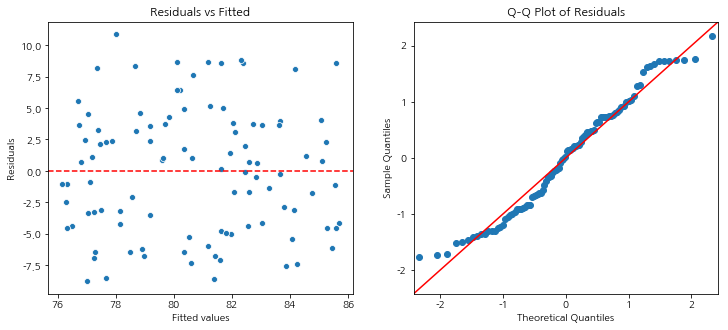

1. Shapiro–Wilk test: W=0.967, p-value=0.014
→ 잔차가 정규성을 만족하지 않음
2. Breusch–Pagan test: χ²=0.038, p-value=0.845
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 2.083
→ 잔차 독립성 가정 만족


In [43]:
# 1. 단순선형회귀 (키→체중 예측)
np.random.seed(0)
n = 100
height = 150 + 20*np.random.rand(n)           # 150cm–170cm
weight = 0.5*height + np.random.normal(0, 5, n)

# 모델 적합
model = sm.OLS(weight, sm.add_constant(height)).fit()
print(model.summary())

#키가 180일 때 몸무게는?
print("\n- 키가 180일때 몸무게: ", model.predict([1, 180])) #상수항 추가


#잔차분석
print("\n<< 잔차 분석 >>")
fitted = model.fittedvalues               # 예측값
residuals = model.resid                   # 잔차

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

# 3) Q–Q 플롯 (정규성 확인)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q–Q Plot of Residuals')
plt.show()

# 4) Shapiro–Wilk 검정 (정규성)
stat, p_value = shapiro(residuals)
print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
if p_value < 0.05:
    print('→ 잔차가 정규성을 만족하지 않음')
else:
    print('→ 잔차가 정규성을 만족함')

# 5) Breusch–Pagan 검정 (등분산성)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
if bp_pvalue < 0.05:
    print('→ 등분산성 가정 위배')
else:
    print('→ 등분산성 가정 만족')

# 6) Durbin–Watson 검정 (독립성/자기상관)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f'3. Durbin–Watson statistic: {dw:.3f}')
if dw < 1.5 or dw > 2.5:
    print('→ 잔차에 자기상관 의심')
else:
    print('→ 잔차 독립성 가정 만족')

**모델 개요**  
– 종속변수 y, 독립변수 x₁ 사용한 단순선형회귀(OLS)  
– 관측치 100개, 모형 자유도 1  

**모형 적합도**  
– 결정계수 R²=0.239, 수정된 R²=0.231  
  -  전체 분산 중 약 23.9% 가 x₁로 설명됨  
– F-통계량 30.79, p-값 2.45e-07 (0.05)  
  - 모델이 통계적으로 유의 
– Omnibus p=0.003  
  -  다소 왜도·첨도 차이 존재 시사  
– Cond. No.≈4.4e+03  
  -  x₁ 스케일에 비해 높은 수치이지만 다중공선성 대상 아님(단일 변수)  

**종합 평가**  
– x₁은 y 예측에 통계적으로 유의하며, 모델이 유의미하나 설명력(R²≈0.24)은 중간 수준  
– 잔차 정규성·독립성, 등분산성 가정 대체로 충족(JB에서는 정규성을 만족한다고 하나, Shapiro는 아님)  
– 추가 변수 도입이나 비선형 모형 검토로 설명력 개선 가능

### **1-1-2. 다중선형회귀 (Multiple Linear Regression)**

**특징:**
- 독립변수 2개 이상, 종속변수 1개
- 회귀식: `y = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ + ε`

**잔차 가정:**
- 단순선형회귀의 모든 가정 +
- **다중공선성 없음**: 독립변수들 간 높은 상관관계 없어야 함 (VIF  관측치)

**사용예:**
- 집값 예측 (면적, 위치, 연식, 층수)
- 급여 예측 (학력, 경력, 직급, 지역)
- 매출 예측 (광고비, 계절성, 가격, 경쟁사)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     741.4
Date:                Sun, 24 Aug 2025   Prob (F-statistic):           1.69e-59
Time:                        22:12:02   Log-Likelihood:                -1061.6
No. Observations:                 100   AIC:                             2129.
Df Residuals:                      97   BIC:                             2137.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5830.2715   4074.127     -1.431      0.1

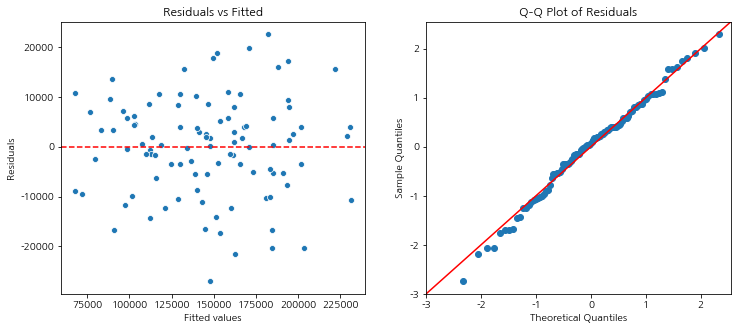

1. Shapiro–Wilk test: W=0.990, p-value=0.685
→ 잔차가 정규성을 만족함
2. Breusch–Pagan test: χ²=3.499, p-value=0.174
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 2.019
→ 잔차 독립성 가정 만족


In [44]:
# 2. 다중선형회귀 (면적, 방수→집값)
np.random.seed(1)
n = 100
area = 50 + 100*np.random.rand(n)
rooms = np.random.randint(1,5,n)
price = 1000*area + 20000*rooms + np.random.normal(0,10000,n)

X = np.column_stack([area, rooms])

# 잔차 진단
model = sm.OLS(price, sm.add_constant(X)).fit()
print(model.summary())


#150, 방 3개일 때 가격?
print("\n- 150, 방 3개일 때 가격: ", model.predict([1, 150, 3])) #상수항 추가


#잔차분석
print("\n<< 잔차 분석 >>")
fitted = model.fittedvalues               # 예측값
residuals = model.resid                   # 잔차

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

# 3) Q–Q 플롯 (정규성 확인)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q–Q Plot of Residuals')
plt.show()

# 4) Shapiro–Wilk 검정 (정규성)
stat, p_value = shapiro(residuals)
print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
if p_value < 0.05:
    print('→ 잔차가 정규성을 만족하지 않음')
else:
    print('→ 잔차가 정규성을 만족함')

# 5) Breusch–Pagan 검정 (등분산성)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
if bp_pvalue < 0.05:
    print('→ 등분산성 가정 위배')
else:
    print('→ 등분산성 가정 만족')

# 6) Durbin–Watson 검정 (독립성/자기상관)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f'3. Durbin–Watson statistic: {dw:.3f}')
if dw < 1.5 or dw > 2.5:
    print('→ 잔차에 자기상관 의심')
else:
    print('→ 잔차 독립성 가정 만족')


**모델 개요**  
– 종속변수 y, 독립변수 x₁, x₂로 구성된 다중선형회귀(OLS)  
– 관측치 100개, 모형 자유도 2  

**모형 적합도**  
– 결정계수 R²=0.939, 수정된 R²=0.937  
  -  전체 분산 중 약 93.9%가 x₁ 및 x₂로 설명됨  
– F-통계량 741.4, p-값 1.69e-59 (0.05)  
  -  통계적으로 유의한 모델  
– Omnibus p = 0.599 (>0.05)  
  -  잔차의 왜도·첨도 이상 없음  
– Cond. No. = 421  
  -  다중공선성 위험은 낮음 (일반적으로 1 000 미만 양호)  

**종합 평가**  
– x₁과 x₂ 모두 y 예측에 매우 유의하며, 모형의 설명력이 매우 높음(R²≈0.94)  
– 잔차의 독립성, 정규성, 등분산성 가정 모두 충족  
– 절편의 통계적 유의성은 낮으나, 독립변수들의 기여도가 매우 크므로 실질적 영향은 제한적  
– 과적합 우려는 낮으며, 추가 변수 도입 없이도 안정적 예측 가능

                 Generalized Linear Model Regression Results                  
Dep. Variable:              accidents   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -449.92
Date:                Mon, 25 Aug 2025   Deviance:                       233.64
Time:                        03:32:52   Pearson chi2:                     223.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2144
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9557      0.106      9.052      0.0

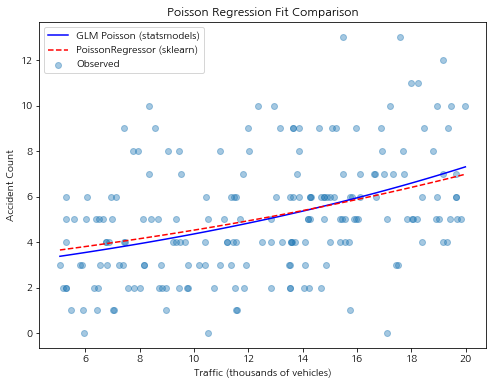

In [109]:
#포아송회귀: 종속변수가 count 변수

import numpy as np
import pandas as pd

# 시드 설정
np.random.seed(0)

# 독립 변수: 일일 차량 통행량 (단위: 천 대)
n_samples = 200
traffic = np.random.uniform(5, 20, size=n_samples)  # 5천~20천

# 종속 변수: 사고 건수 (Poisson 분포)
# 진짜 계수: intercept=1.0, coef=0.05
log_mu = 1.0 + 0.05 * traffic
mu = np.exp(log_mu)
accidents = np.random.poisson(mu)

# DataFrame 구성
df = pd.DataFrame({
    'traffic_k': traffic,
    'accidents': accidents
})
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

# 설명 변수에 절편 추가
X_sm = sm.add_constant(df[['traffic_k']])
y_sm = df['accidents']

# 모델 정의 및 적합
poisson_model = sm.GLM(y_sm, X_sm, family=Poisson())
poisson_result = poisson_model.fit()

# 결과 요약 출력
print(poisson_result.summary())


from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error

# 학습/테스트 분리
X = df[['traffic_k']]
y = df['accidents']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 모델 정의 및 학습
sk_model = PoissonRegressor(alpha=0.0, max_iter=300)
sk_model.fit(X_train, y_train)

# 계수 확인
print("Intercept:", sk_model.intercept_)
print("Coefficient:", sk_model.coef_[0])

# 예측 및 평가
y_pred = sk_model.predict(X_test)
print("Mean Poisson Deviance:", mean_poisson_deviance(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


import matplotlib.pyplot as plt

# 테스트 집합에 대한 예측
traffic_range = np.linspace(df['traffic_k'].min(), df['traffic_k'].max(), 100)
X_range = pd.DataFrame({'traffic_k': traffic_range})
X_range_sm = sm.add_constant(X_range)

# statsmodels 예측
y_range_sm = poisson_result.predict(X_range_sm)
# scikit-learn 예측
y_range_sk = sk_model.predict(X_range)

plt.figure(figsize=(8,6))
# 산점도: 실제 관측값
plt.scatter(df['traffic_k'], df['accidents'], alpha=0.4, label='Observed')
# 회귀선: statsmodels
plt.plot(traffic_range, y_range_sm, color='blue', label='GLM Poisson (statsmodels)')
# 회귀선: scikit-learn
plt.plot(traffic_range, y_range_sk, color='red', linestyle='--', label='PoissonRegressor (sklearn)')
plt.xlabel('Traffic (thousands of vehicles)')
plt.ylabel('Accident Count')
plt.title('Poisson Regression Fit Comparison')
plt.legend()
plt.show()


### **1-1-3. 다변량선형회귀 (Multivariate Linear Regression)**

**특징:**
- 독립변수 여러 개, 종속변수 여러 개
- 행렬 형태: `Y = XB + E`

**잔차 가정:**
- 다중선형회귀의 모든 가정 +
- **종속변수들 간 오차 상관구조** 고려 필요

**장점:**
- 여러 결과변수 동시 모델링
- 변수 간 상관관계 효율적 활용
- 통계적 검정력 향상

**단점:**
- 모델 복잡성 급격히 증가
- 해석이 매우 어려움
- 계산 부담과 메모리 요구량 큼

**사용예:**
- 학생의 국, 영, 수 성적 동시 예측
- 기업의 부문별 매출 예측
- 환자의 다중 생체지표 예측


=== 혈압(bp) 회귀 결과 ===
                            OLS Regression Results                            
Dep. Variable:                     bp   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     174.2
Date:                Sun, 24 Aug 2025   Prob (F-statistic):           7.75e-33
Time:                        22:25:20   Log-Likelihood:                -293.62
No. Observations:                 100   AIC:                             593.2
Df Residuals:                      97   BIC:                             601.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        102.4559      1.68

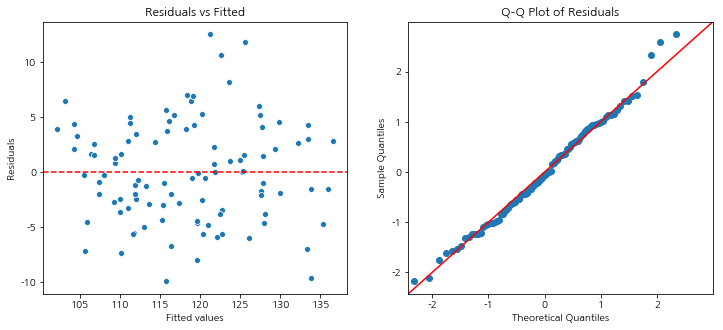

1. Shapiro–Wilk test: W=0.989, p-value=0.599
→ 잔차가 정규성을 만족함
2. Breusch–Pagan test: χ²=2.570, p-value=0.277
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 2.010
→ 잔차 독립성 가정 만족

<< 잔차 분석 : 콜레스테롤>>


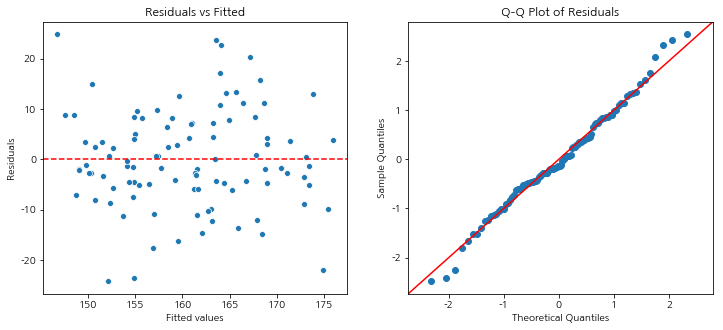

1. Shapiro–Wilk test: W=0.990, p-value=0.662
→ 잔차가 정규성을 만족함
2. Breusch–Pagan test: χ²=0.123, p-value=0.941
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 2.438
→ 잔차 독립성 가정 만족


In [51]:
from sklearn.metrics import mean_squared_error

# 1. 데이터 생성
np.random.seed(0)
n = 100

# 독립변수: 나이(age), 운동시간(exercise)
age      = 20 + 60 * np.random.rand(n)           # 20–80세
exercise = 0  +  5 * np.random.rand(n)           # 0–5시간/주

# 종속변수: 혈압(bp), 콜레스테롤(chol)
# bp와 chol 모두 age와 exercise에 영향을 받음
bp   = 100 + 0.5 * age   - 2.0 * exercise + np.random.normal(0, 5, n)
chol = 150 + 0.3 * age   - 1.0 * exercise + np.random.normal(0,10, n)

# DataFrame 생성
df = pd.DataFrame({
    'age':      age,
    'exercise': exercise,
    'bp':       bp,
    'chol':     chol
})

# 2. 모델 적합 (statsmodels)
# statsmodels에서는 MVRegression 대신 각 종속변수별로 OLS를 따로 적합할 수 있음
X = sm.add_constant(df[['age', 'exercise']])

model_bp   = sm.OLS(df['bp'],   X).fit()
model_chol = sm.OLS(df['chol'], X).fit()

# 결과 출력
print("=== 혈압(bp) 회귀 결과 ===")
print(model_bp.summary())
print("\n=== 콜레스테롤(chol) 회귀 결과 ===")
print(model_chol.summary())

# 3. 예측 및 평가
pred_bp   = model_bp.predict(X)
pred_chol = model_chol.predict(X)

mse_bp   = mean_squared_error(df['bp'],   pred_bp)
mse_chol = mean_squared_error(df['chol'], pred_chol)
print(f"\nMSE (bp):   {mse_bp:.3f}")
print(f"MSE (chol): {mse_chol:.3f}")


def ch_resid(model, name):
# 4. 잔차 진단 (혈압 모델)
    print(f"\n<< 잔차 분석 : {name}>>")
    residuals = model.resid
    fitted= model.fittedvalues

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    # 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
    sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
    ax[0].axhline(0, color='red', linestyle='--')
    ax[0].set_xlabel('Fitted values')
    ax[0].set_ylabel('Residuals')
    ax[0].set_title('Residuals vs Fitted')

    # 3) Q–Q 플롯 (정규성 확인)
    qqplot(residuals, line='45', fit=True, ax=ax[1])
    ax[1].set_title('Q–Q Plot of Residuals')
    plt.show()

    # 4) Shapiro–Wilk 검정 (정규성)
    stat, p_value = shapiro(residuals)
    print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print('→ 잔차가 정규성을 만족하지 않음')
    else:
        print('→ 잔차가 정규성을 만족함')

    # 5) Breusch–Pagan 검정 (등분산성)
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
    print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
    if bp_pvalue < 0.05:
        print('→ 등분산성 가정 위배')
    else:
        print('→ 등분산성 가정 만족')

    # 6) Durbin–Watson 검정 (독립성/자기상관)
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals)
    print(f'3. Durbin–Watson statistic: {dw:.3f}')
    if dw < 1.5 or dw > 2.5:
        print('→ 잔차에 자기상관 의심')
    else:
        print('→ 잔차 독립성 가정 만족')

ch_resid(model_bp, "혈압")
ch_resid(model_chol, "콜레스테롤")

두 모델 모두 통계적으로 유의한 모델이며, 잔차의 가정을 모두 만족한다.  
다만 두 모델 중 하나의 모델만 선택해야 한다면 모델의 설명력이 높으며, AIC가 낮은 혈액모델을 선택한다.

## **1-2. 비선형회귀 (Nonlinear Regression)**

***
### **1-2-1. 다항회귀 (Polynomial Regression)**

**특징:**
- 독립변수의 거듭제곱 항 포함
- 회귀식: `y = β₀ + β₁x + β₂x² + β₃x³ + ... + ε`

**잔차 가정:**
- **선형회귀와 동일한 모든 가정 적용**
- 다항변환 후에도 여전히 선형모델이므로
- **적절한 차수 선택** 중요 (과적합 방지)

**장점:**
- 비선형 패턴 포착 가능
- 선형회귀 기법 그대로 적용
- 곡선 관계 모델링 적합

**단점:**
- 과적합 위험 매우 높음
- 차수 선택의 어려움
- 외삽(extrapolation) 시 불안정

**사용예:**
- 성장곡선 (나이-키 관계)
- 수익률-위험 관계 (포트폴리오)
- 용량-반응 곡선 (약물효과)

MSE: 78.269
R² : 0.936

<< 잔차 분석 >>


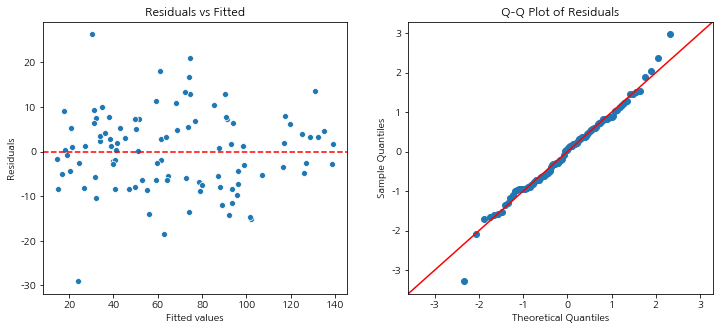

1. Shapiro–Wilk test: W=0.991, p-value=0.711
→ 잔차가 정규성을 만족함
2. Breusch–Pagan test: χ²=0.445, p-value=0.801
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 1.995
→ 잔차 독립성 가정 만족


In [54]:
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 생성
np.random.seed(3)
n = 100
speed = 20 + 80*np.random.rand(n)
dist  = 0.01*speed**2 + 0.5*speed + np.random.normal(0, 10, n)

# 모델 적합
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_model.fit(speed.reshape(-1,1), dist)
pred = poly_model.predict(speed.reshape(-1,1))
resid = dist - pred

# 예측 평가
mse = mean_squared_error(dist, pred)
r2  = r2_score(dist, pred)
print(f"MSE: {mse:.3f}")
print(f"R² : {r2:.3f}")

print(f"\n<< 잔차 분석 >>")
residuals = resid
fitted= pred

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

# 3) Q–Q 플롯 (정규성 확인)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q–Q Plot of Residuals')
plt.show()

# 4) Shapiro–Wilk 검정 (정규성)
stat, p_value = shapiro(residuals)
print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
if p_value < 0.05:
    print('→ 잔차가 정규성을 만족하지 않음')
else:
    print('→ 잔차가 정규성을 만족함')

# 5) Breusch–Pagan 검정 (등분산성)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
if bp_pvalue < 0.05:
    print('→ 등분산성 가정 위배')
else:
    print('→ 등분산성 가정 만족')

# 6) Durbin–Watson 검정 (독립성/자기상관)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f'3. Durbin–Watson statistic: {dw:.3f}')
if dw < 1.5 or dw > 2.5:
    print('→ 잔차에 자기상관 의심')
else:
    print('→ 잔차 독립성 가정 만족')

### **1-2-2. 지수회귀 (Exponential Regression)**

**특징:**
- 지수함수 형태: `y = ae^(bx)`
- 로그변환으로 선형화: `ln(y) = ln(a) + bx`

**잔차 가정:**
- **로그변환 후** 선형회귀 가정 적용
- 원데이터에서는 **등분산성 위배** 가능성 높음
- **양수 종속변수** 필수 조건

**장점:**
- 지수적 성장/감쇠 모델링에 최적
- 로그변환으로 선형화 가능
- 성장률 해석 용이

**단점:**
- 제한적 함수 형태
- 음수값 처리 불가
- 이상치에 매우 민감

**사용예:**
- 인구 증가 모델
- 방사능 물질 반감기
- COVID-19 확산 모델
- 복리 계산

MSE: 0.025
R² : 0.970

<< 잔차 분석 >>


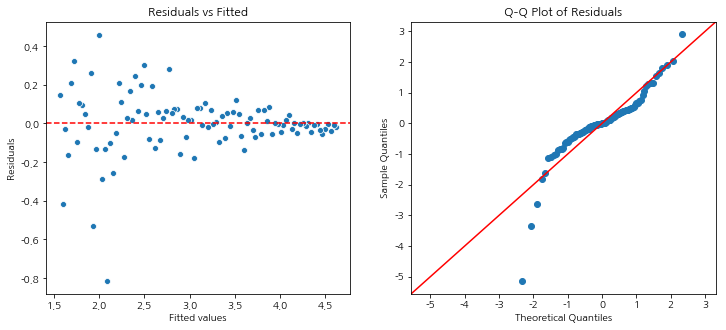

1. Shapiro–Wilk test: W=0.859, p-value=0.000
→ 잔차가 정규성을 만족하지 않음
2. Breusch–Pagan test: χ²=2.181, p-value=0.336
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 1.985
→ 잔차 독립성 가정 만족


In [55]:
# 5. 지수회귀 (시간→방사능 감쇠)
np.random.seed(4)
n = 100
t = np.linspace(0,10,n)
a, b = 100, -0.3
radio = a * np.exp(b*t) + np.random.normal(0,2,n)

# 로그변환 선형화
log_radio = np.log(radio.clip(min=1e-3))
exp_model = LinearRegression().fit(t.reshape(-1,1), log_radio)
pred_log = exp_model.predict(t.reshape(-1,1))
resid = log_radio - pred_log

# 예측 평가
mse = mean_squared_error(log_radio, pred_log)
r2  = r2_score(log_radio, pred_log)
print(f"MSE: {mse:.3f}")
print(f"R² : {r2:.3f}")

print(f"\n<< 잔차 분석 >>")
residuals = resid
fitted= pred_log

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

# 3) Q–Q 플롯 (정규성 확인)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q–Q Plot of Residuals')
plt.show()

# 4) Shapiro–Wilk 검정 (정규성)
stat, p_value = shapiro(residuals)
print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
if p_value < 0.05:
    print('→ 잔차가 정규성을 만족하지 않음')
else:
    print('→ 잔차가 정규성을 만족함')

# 5) Breusch–Pagan 검정 (등분산성)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
if bp_pvalue < 0.05:
    print('→ 등분산성 가정 위배')
else:
    print('→ 등분산성 가정 만족')

# 6) Durbin–Watson 검정 (독립성/자기상관)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f'3. Durbin–Watson statistic: {dw:.3f}')
if dw < 1.5 or dw > 2.5:
    print('→ 잔차에 자기상관 의심')
else:
    print('→ 잔차 독립성 가정 만족')

### **1-2-3. 로그회귀 (Logarithmic Regression)**

**특징:**
- 로그함수 형태: `y = a + b×ln(x)`
- 수확체감 현상 모델링

**잔차 가정:**
- **로그변환 후** 선형회귀 가정 적용
- **양수 독립변수** 필수 조건
- 로그변환이 분산 안정화 효과

**장점:**
- 수확체감 법칙 모델링 적합
- 탄력성 해석 용이 (% 변화)
- 큰 값의 영향 완화

**단점:**
- 음수/0 값 처리 불가
- 제한적 함수 형태
- 초기값 민감도

**사용예:**
- 소득-소비 관계 (엥겔곡선)
- 학습시간-성과 관계
- 광고비-매출 효과 (S-curve)

MSE: 2679.952
R² : 0.979

<< 잔차 분석 >>


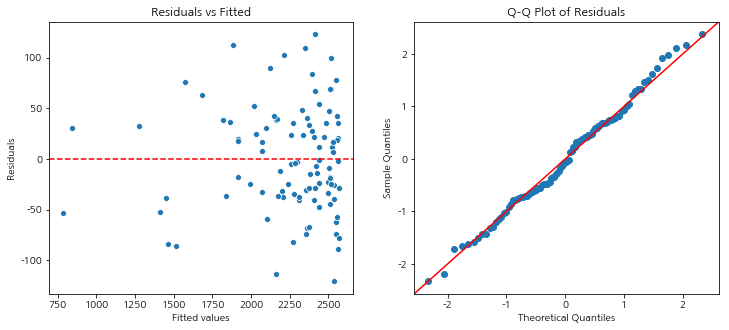

1. Shapiro–Wilk test: W=0.990, p-value=0.633
→ 잔차가 정규성을 만족함
2. Breusch–Pagan test: χ²=2.667, p-value=0.264
→ 등분산성 가정 만족
3. Durbin–Watson statistic: 1.640
→ 잔차 독립성 가정 만족


In [56]:
# 6. 로그회귀 (광고비→매출)
np.random.seed(5)
n = 100
ad = 1 + 1000*np.random.rand(n)
sales = 500 + 300*np.log(ad) + np.random.normal(0,50,n)

logX = np.log(ad)
log_model = LinearRegression().fit(logX.reshape(-1,1), sales)
pred = log_model.predict(logX.reshape(-1,1))
resid = sales - pred

# 예측 평가
mse = mean_squared_error(sales, pred)
r2  = r2_score(sales, pred)
print(f"MSE: {mse:.3f}")
print(f"R² : {r2:.3f}")

print(f"\n<< 잔차 분석 >>")
residuals = resid
fitted= pred

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# 2) 잔차 vs 적합값 산점도 (등분산성·선형성 확인)
sns.scatterplot(x=fitted, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted')

# 3) Q–Q 플롯 (정규성 확인)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q–Q Plot of Residuals')
plt.show()

# 4) Shapiro–Wilk 검정 (정규성)
stat, p_value = shapiro(residuals)
print(f'1. Shapiro–Wilk test: W={stat:.3f}, p-value={p_value:.3f}')
if p_value < 0.05:
    print('→ 잔차가 정규성을 만족하지 않음')
else:
    print('→ 잔차가 정규성을 만족함')

# 5) Breusch–Pagan 검정 (등분산성)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f'2. Breusch–Pagan test: χ²={bp_stat:.3f}, p-value={bp_pvalue:.3f}')
if bp_pvalue < 0.05:
    print('→ 등분산성 가정 위배')
else:
    print('→ 등분산성 가정 만족')

# 6) Durbin–Watson 검정 (독립성/자기상관)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f'3. Durbin–Watson statistic: {dw:.3f}')
if dw < 1.5 or dw > 2.5:
    print('→ 잔차에 자기상관 의심')
else:
    print('→ 잔차 독립성 가정 만족')


### **1-2-4. 베이즈회귀 (Bayesian Regression)**

**특징:**
- 베이즈 정리 기반 확률적 접근
- 사전분포 × 우도함수 = 사후분포

**잔차 가정:**
- **전통적 잔차 가정과 완전히 다른 접근**
- 정규성, 등분산성 가정 불필요
- **사전분포 설정**과 **사후분포 수렴성**이 핵심
- **MCMC 수렴 진단** 필요

**장점:**
- 불확실성 정량화 (신뢰구간 자연스럽게 제공)
- 사전정보 활용 가능
- 과적합 자연스럽게 방지 (정규화 효과)
- 소규모 데이터에서도 안정적

**단점:**
- 계산 복잡도 매우 높음 (MCMC)
- 사전분포 선택의 주관성
- 수렴성 문제 가능
- 해석이 상대적으로 어려움

**사용예:**
- 의료 진단 및 예후 모델
- 금융 리스크 평가
- A/B 테스트 분석
- 임상시험 중간분석

In [59]:
from scipy.stats import norm

# 7. 베이즈회귀 (물가→소비지출)
# 데이터 생성
np.random.seed(6)
n = 100
price = 50 + 10*np.random.rand(n)
consumption = 100 - 0.8*price + np.random.normal(0, 2, n)

# 베이즈 회귀 모델 적합
bayes = BayesianRidge().fit(price.reshape(-1,1), consumption)
pred = bayes.predict(price.reshape(-1,1))
resid = consumption - pred

# 1) 계수 사후분포 요약 (평균 ± 2σ)
coef_mean = bayes.coef_[0]
coef_var  = bayes.sigma_[0,0]
intercept_mean = bayes.intercept_
intercept_var  = bayes.sigma_[-1,-1]  # intercept posterior variance

coef_ci = norm.ppf([0.025, 0.975], loc=coef_mean, scale=np.sqrt(coef_var))
intercept_ci = norm.ppf([0.025, 0.975], loc=intercept_mean, scale=np.sqrt(intercept_var))

print(f"Coefficient mean: {coef_mean:.3f}, 95% CI: [{coef_ci[0]:.3f}, {coef_ci[1]:.3f}]")
print(f"Intercept mean: {intercept_mean:.3f}, 95% CI: [{intercept_ci[0]:.3f}, {intercept_ci[1]:.3f}]")

# 2) 예측 성능
mse = mean_squared_error(consumption, pred)
r2  = r2_score(consumption, pred)
print(f"MSE: {mse:.3f}, R²: {r2:.3f}")


# 7) Durbin–Watson 검정 (독립성)
dw = durbin_watson(resid)
print(f"Durbin–Watson: {dw:.3f}")

Coefficient mean: -0.816, 95% CI: [-0.939, -0.692]
Intercept mean: 100.737, 95% CI: [100.614, 100.861]
MSE: 2.944, R²: 0.630
Durbin–Watson: 1.982



## **1-3. 종합 비교표**

| 회귀유형 | 독립변수 | 종속변수 | 잔차가정 | 복잡도 | 해석성 | 계산비용 |
|---------|---------|---------|---------|--------|--------|----------|
| 단순선형 | 1개 | 1개 | 4가지 모두 | 낮음 | 매우높음 | 낮음 |
| 다중선형 | 2개이상 | 1개 | 4가지+다중공선성 | 중간 | 높음 | 낮음 |
| 다변량선형 | 2개이상 | 2개이상 | 4가지+상관구조 | 높음 | 낮음 | 중간 |
| 다항회귀 | 1개이상 | 1개 | 선형회귀와 동일 | 중간 | 중간 | 중간 |
| 지수회귀 | 1개이상 | 1개 | 변환후 적용 | 중간 | 중간 | 중간 |
| 로그회귀 | 1개이상 | 1개 | 변환후 적용 | 중간 | 높음 | 중간 |
| 베이즈회귀 | 1개이상 | 1개이상 | 불필요 | 높음 | 중간 | 매우높음 |

***

## **4. 실무 적용 가이드**

### **모델 선택 기준:**
1. **데이터 크기**: 소규모 → 베이즈, 대규모 → 전통적 방법
2. **관계 형태**: 선형 → 선형회귀, 곡선 → 다항/비선형
3. **해석 중요도**: 높음 → 단순선형, 낮음 → 복잡한 모델
4. **불확실성**: 중요 → 베이즈, 덜 중요 → 빈도주의 방법

### **잔차 진단 방법:**
- **잔차 플롯**: 등분산성, 선형성 확인
- **Q-Q 플롯**: 정규성 확인  
- **D-W 검정**: 독립성 확인
- **VIF**: 다중공선성 확인

# 2. 종속변수 유형에 따른 회귀·분류 기법 

***

## 2-1. 연속형 종속변수 대상

### 2-1-1. 일반선형회귀 (Ordinary Least Squares, OLS): 상동

### 2-1-2. 릿지회귀 (Ridge Regression)

특징  
- OLS 손실에 L2 패널티(λ ∑βᵢ²) 추가  
- 과적합 완화, 모든 계수를 작게 유지

전제조건  
- OLS 전제조건(선형성·독립성·등분산성·정규성)  
- λ 하이퍼파라미터 선택

장점  
- 다중공선성에 강함  
- 과적합 방지  
- 해석 가능성 유지

단점  
- 계수를 완전히 0으로 만들지 않음(특성 선택 불가)  
- λ 최적화(교차검증 필요)

사용 예  
- 설명변수 간 상관 강할 때  
- 변수 개수 많으나 제거 않고 모두 활용할 때

In [67]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

X = data['data']
Y = data['target']

dt = pd.DataFrame(np.c_[X, Y], columns=data['feature_names']+['target'])
display(dt.head(3))

from sklearn.linear_model import Ridge

x = dt.drop(columns=['target'])
y = dt['target']

rg = Ridge(alpha=0.9).fit(x, y)

#r2 score
print("R2 Score:", rg.score(x, y).round(3))

#계수+절편
for i, coef in enumerate(rg.coef_):
    print(f"회귀계수 {i}: {coef:.3f}")
print(f"절편: {rg.intercept_:.3f}")

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0


R2 Score: 0.458
회귀계수 0: 28.263
회귀계수 1: -90.424
회귀계수 2: 318.844
회귀계수 3: 208.773
회귀계수 4: 2.971
회귀계수 5: -34.092
회귀계수 6: -156.112
회귀계수 7: 118.538
회귀계수 8: 273.262
회귀계수 9: 112.556
절편: 152.133


### 2-1-3. 라쏘회귀 (Lasso Regression): L1 규제

특징  
- OLS 손실에 L1 패널티(λ ∑|βᵢ|) 추가  
- 일부 계수를 0으로 만들어 특성 선택 효과

전제조건  
- OLS 전제조건  
- λ 하이퍼파라미터 선택

장점  
- 자동 특성 선택  
- 모델 단순화  
- 과적합 완화

단점  
- 강한 상관변수 중 하나만 선택  
- λ 민감도 높음

사용 예  
- 많은 특성 중 일부만 중요할 때  
- 해석성과 변수 축소가 필요할 때

In [69]:
from sklearn.linear_model import Lasso

rsso = Lasso(alpha=0.9).fit(x, y)

#r2 score
print("R2 Score:", rsso.score(x, y).round(3))

#계수+절편
for i, coef in enumerate(rsso.coef_):
    print(f"회귀계수 {i}: {coef:.3f}")
print(f"절편: {rsso.intercept_:.3f}")

R2 Score: 0.381
회귀계수 0: 0.000
회귀계수 1: -0.000
회귀계수 2: 391.240
회귀계수 3: 31.897
회귀계수 4: 0.000
회귀계수 5: 0.000
회귀계수 6: -0.000
회귀계수 7: 0.000
회귀계수 8: 331.233
회귀계수 9: 0.000
절편: 152.133


### 2-1-4. 엘라스틱넷 (Elastic Net)

특징  
- L1 + L2 결합 패널티: λ₁∑|βᵢ| + λ₂∑βᵢ²  
- 라쏘와 릿지 장점 통합

전제조건  
- OLS 전제조건  
- λ₁, λ₂ 두 개 하이퍼파라미터 최적화

장점  
- 상관변수 묶음 선택 가능  
- 과적합 완화 및 특성 선택  
- 유연한 페널티 조합

단점  
- 하이퍼파라미터 튜닝 복잡  
- 계산 비용 증가

사용 예  
- 변수 간 상관성과 희소성 모두 고려할 때  
- 고차원 데이터에서 특성 선택과 안정적 예측 둘 다 필요할 때

In [76]:
from sklearn.linear_model import ElasticNet

el = ElasticNet(alpha=0.2, l1_ratio=0.8).fit(x, y) #규제정도 a, l1_ratio 는 l1의 비율, 나머지는 l2 비율

#r2 score
print("R2 Score:", el.score(x, y).round(3))

#계수+절편
for i, coef in enumerate(el.coef_):
    print(f"회귀계수 {i}: {coef:.3f}")
print(f"절편: {el.intercept_:.3f}")

R2 Score: 0.115
회귀계수 0: 9.853
회귀계수 1: 0.000
회귀계수 2: 43.377
회귀계수 3: 31.129
회귀계수 4: 10.793
회귀계수 5: 7.372
회귀계수 6: -26.824
회귀계수 7: 28.472
회귀계수 8: 40.856
회귀계수 9: 25.303
절편: 152.133


## 2-2. 범주형 종속변수 대상

## **요약 비교표**

| 분류기준     | 기법                   | 종속변수 유형 | 전제조건                        | 장점                                 | 단점                        | 사용 예                               |
|------------|----------------------|-------------|-------------------------------|------------------------------------|---------------------------|------------------------------------|
| 연속형       | 일반선형회귀 (OLS)        | 연속        | 잔차 4가지 가정               | 해석·구현 간단, 통계 검정 가능       | 이상치 민감, 선형만        | 매출, 집값 예측                        |
|            | Ridge                | 연속        | OLS + λ 최적화               | 다중공선성, 과적합 완화             | 특성 선택 불가             | 고차원 다중공선성 데이터               |
|            | Lasso                | 연속        | OLS + λ 최적화               | 자동 특성 선택                     | λ 민감, 상관변수 처리 이슈  | 변수 선택과 예측 동시에 필요할 때      |
|            | Elastic Net          | 연속        | OLS + λ₁,λ₂ 최적화           | 과적합 방지·특성 선택               | 하이퍼파라미터 튜닝 복잡    | 희소성과 상관성 모두 고려해야 할 때     |
| 범주형       | Logistic             | 이진        | 선형판별, 독립성, 다중공선성 최소화 | 확률 예측, 오즈비 해석              | 비선형 경계 포착 불가       | 스팸 분류, 이탈 예측                   |
|            | Multinomial Logistic | 다중        | Logistic 전제조건             | 다중 클래스 확률 제공              | 파라미터 급증, 계산 비용     | 숫자 분류, 설문 다항 응답               |
|            | Ordinal Logistic     | 순서형      | Logistic 전제조건 + 비례오즈 가정 | 순서 정보 반영, 오즈비 해석 가능     | 가정 위배 시 부정확, 복잡    | 만족도 조사, 신용 등급, 질병 단계        |


### 2-2-1. 로지스틱회귀 (Logistic Regression)

특징  
- 이진 종속변수 예측  
- 시그모이드 함수로 확률 예측:  
  $$P(y=1|x)=\frac{1}{1+e^{-(β₀+βᵗx)}}$$  
- 최대우도법으로 추정

전제조건  
1. 선형판별성(linear decision boundary)  
2. 독립성(independence)  
3. 다중공선성 최소화  
4. 대규모 샘플 권장(추정 안정성)

장점  
- 확률 출력 및 해석 용이(오즈비)  
- 이진 분류 표준 기법  
- 과적합 방지 옵션(정규화) 존재

단점  
- 비선형 경계 포착 불가  
- 이상치 민감  
- 다중공선성 영향 큼

사용 예  
- 스팸 여부 분류, 질병 유무 예측, 고객 이탈 예측

In [88]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression


data = load_breast_cancer()

X  = data.data[:, :4]
y = data.target

x = pd.DataFrame(X, columns=data.feature_names[:4])


lr = LogisticRegression(C=0.01, max_iter=1000) #C가 높을수록 규제가 약해지며, 복잡성 증가
lr.fit(x, y)

score = lr.score(x, y)


ss = 'y = '

for i, coef in enumerate(lr.coef_.ravel()):
    ss += f"{coef:.3f} * {x.columns[i]} + "
ss += f"{lr.intercept_[0]:.3f}"

print(f"회귀식: {ss}")


# classificatin report
from sklearn.metrics import classification_report

pred = lr.predict(x)

print(classification_report(y, pred))


# 오즈비 계산
odds_ratios = np.exp(lr.coef_[0])

# 결과를 DataFrame으로 보기 좋게 출력
odds_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_[0],
    '오즈비': odds_ratios
})

display(odds_df)

회귀식: y = 0.032 * mean radius + -0.194 * mean texture + -0.288 * mean perimeter + 0.010 * mean area + 24.520
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       212
           1       0.91      0.94      0.92       357

    accuracy                           0.90       569
   macro avg       0.90      0.89      0.89       569
weighted avg       0.90      0.90      0.90       569



,Feature,Coefficient,오즈비
0,mean radius,0.031776,1.032287
1,mean texture,-0.194117,0.823562
2,mean perimeter,-0.288131,0.749663
3,mean area,0.009537,1.009583


### 2-2-2. 다항로지스틱회귀 (Multinomial Logistic Regression)

특징  
- 종속변수 다중(세 개 이상) 범주  
- 소프트맥스 함수로 각 클래스 확률 예측  
- 최대우도법 추정

전제조건  
- 로지스틱 회귀 전제조건  
- 각 클래스 간 독립성 가정(IID)

장점  
- 다중 클래스 확률 제공  
- 이진 로지스틱과 비슷한 해석 가능  
- 정규화 적용 가능

단점  
- 클래스 수 늘면 파라미터 수 급증  
- 계산 비용 증가  
- 불균형 시 성능 저하 가능

사용 예  
- 손글씨 숫자 분류, 고객 세분화, 선호도 조사

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.87        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



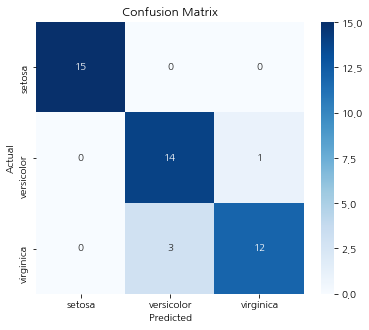

In [97]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Iris 데이터셋 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 학습/테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 특성 스케일링(Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 다항 분류(multi_class='multinomial') + 솔버로 'lbfgs' 사용
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=200,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# 분류 성능 지표 출력
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 2-2-3. 순서로지스틱회귀 (Ordinal Logistic Regression)

특징  
- 순서형 범주 대상(예: “낮음-보통-높음”)  
- 누적 로짓(cumulative logit) 모델:  
  $$\ln\frac{P(Y\le k)}{P(Y>k)}=α_k−βᵗx$$  
- 계수 β는 모든 컷포인트에 공통

전제조건  
1. **비례오즈 가정**(proportional odds): β가 모든 컷포인트에서 동일  
2. 독립성, 다중공선성 최소화

장점  
- 순서 정보 반영  
- 로지스틱과 유사 해석(오즈비)  
- 컷포인트 별 분류 한 번에 수행

단점  
- 비례오즈 가정 위배 시 모델 부정확  
- 컷포인트 설정 민감  
- 복잡한 추정 및 진단 필요

사용 예  
- 설문 응답(매우 불만족→매우 만족), 질병 단계, 신용 등급


                             OrderedModel Results                             
Dep. Variable:                  class   Log-Likelihood:                -1084.9
Model:                   OrderedModel   AIC:                             2202.
Method:            Maximum Likelihood   BIC:                             2282.
Date:                Mon, 25 Aug 2025                                         
Time:                        03:24:27                                         
No. Observations:                1119                                         
Df Residuals:                    1103                                         
Df Model:                          16                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fixed_acidity           -0.0016      0.171     -0.009      0.993      -0.336       0.333
volatile_acidity      

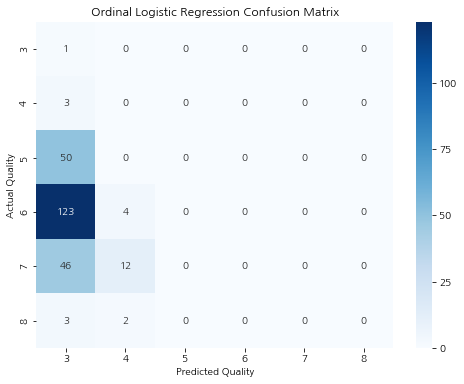

In [104]:
from sklearn.datasets import fetch_openml
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import confusion_matrix, classification_report

# 1. 데이터 로드 및 준비
wine = fetch_openml(name='wine-quality-red', version=1, as_frame=True)
df = wine.frame.copy()

# 종속 변수 y: quality (3~8 정수)
y = df['class'].astype(int)
X = df.drop(columns='class')

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. 특성 스케일링 (옵션)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# statsmodels는 DataFrame 입력을 선호하므로 다시 변환
X_train_s = pd.DataFrame(X_train_s, columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(X_test_s,  columns=X.columns, index=X_test.index)

# 3. 순서 로지스틱 회귀 모델 정의 및 학습
#    - distr: 링크 함수 ('logit', 'probit', 'cloglog' 중 선택 가능)
model = OrderedModel(
    endog=y_train,
    exog=X_train_s,
    distr='logit'
)
result = model.fit(method='bfgs', disp=False)
print(result.summary())

# 4. 예측 및 평가
#    - 모델.predict()는 각 클래스에 속할 확률을 반환
pred_probs = result.model.predict(result.params, exog=X_test_s)
#    - 확률이 가장 높은 클래스를 예측값으로 사용
y_pred = pred_probs.argmax(axis=1).astype(int)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Ordinal Logistic Regression Confusion Matrix')
plt.show()


# 3. 특수 목적 회귀 기법

종속변수가 연속형이지만, **분석 목적**이나 **데이터 특성**이 일반 회귀와 다를 때 사용하는 대표 기법들이다. 각각의 특징, 전제조건, 장·단점, 사용 예시를 정리하였다.

***

### **요약 비교표**

| 분류            | 기법             | 주요 전제조건                  | 장점                              | 단점                             | 사용 예                       |
|---------------|----------------|-----------------------------|---------------------------------|--------------------------------|------------------------------|
| 시계열 회귀      | AR(p)           | 정상성, 백색잡음               | 단기 예측 강함, 해석 쉬움          | 정상성 필요, 장기 의존성 포착 어려움 | 주가, 기온 예측               |
|          -     | MA(q)           | 정상성, 백색잡음               | 이상치 충격 모델링 유리           | 오차항 관측 불가, 장기 의존성 불가    | 생산 오차 분석, 경제지표       |
|       -        | ARIMA(p,d,q)    | 차분 후 정상성, 백색잡음        | 비정상 시계열 모델링 가능         | 모형 식별 복잡, 계절성 한계         | 매출·환율·수요 예측           |
| 생존분석 회귀    | Cox            | 비례위험, 독립검열             | 검열 활용, 유연성                | 비례위험 위배 시 부정확             | 환자 생존분석, 장비 고장 시간    |
|          -     | Weibull        | Weibull 분포 적합성, 독립검열   | 파라메트릭, 예측·해석 용이        | 분포 가정 제한적                  | 신뢰성 시험, 임상시험          |
| 분위수 회귀      | Quantile       | 선형관계, 잔차 독립             | 분포 전체 예측, 이상치 강건       | 계산 비용, 해석 복잡               | 주택 가격 분포, 금융 VaR 예측    |



## 3-1. 시계열 회귀 (Time Series Regression)

시계열 데이터는 **시간 순서**에 따른 관측치이므로, 일반 회귀의 독립성 가정이 위배된다. 이에 대응하는 대표 기법들:

### ① 자기회귀 모형 (AutoRegressive, AR)

- **특징**  
  - 현재값을 과거 시점의 값들로 설명  
  - AR(p): $$X_t = c + \sum_{i=1}^{p}\phi_i X_{t-i} + \epsilon_t$$

- **전제조건**  
  1. **정상성(Stationarity)**: 평균·분산·자기공분산이 시간에 따라 일정  
  2. **백색잡음(εₜ)**: 평균 0, 분산 일정, 비상관

- **장점**  
  - 단순 구조, 해석 쉬움  
  - 단기 예측에 강함

- **단점**  
  - 정상성 필요, 비정상 시 변환(차분) 필요  
  - 장기 의존성 포착 어려움

- **사용 예**  
  - 주가 일별 종가 예측  
  - 기온·강수량 예측  
  - 전력 소비량 예측

***

### ② 이동평균 모형 (Moving Average, MA)

- **특징**  
  - 현재값을 과거 오차항들의 선형결합으로 설명  
  - MA(q): $$X_t = \mu + \sum_{i=1}^{q}\theta_i \epsilon_{t-i} + \epsilon_t$$

- **전제조건**  
  1. **정상성**  
  2. **백색잡음 εₜ**

- **장점**  
  - 갑작스러운 충격(이상치) 영향 모델링에 유리  
  - 구조 간단

- **단점**  
  - 장기 의존성 포착 불가  
  - 오차항 εₜ 관측 불가 → θ 추정 복잡

- **사용 예**  
  - 생산 공정 오차 분석  
  - 경제지표 단기 변동 설명  
  - 재고 관리 예측

***

### ③ ARIMA (AutoRegressive Integrated Moving Average)

- **특징**  
  - AR + 차분(Integrated) + MA 결합: ARIMA(p, d, q)  
  - $$ \Delta^d X_t $$를 AR(p) + MA(q)로 모델링

- **전제조건**  
  1. **차분 후 정상성**  
  2. **백색잡음 εₜ**

- **장점**  
  - 비정상 시계열(추세, 계절성 일부 제거) 모델링 가능  
  - 다용도 예측 성능 우수

- **단점**  
  - 모형 식별(p, d, q 선택) 복잡  
  - 계절성·비선형 패턴 포착 어려움 → SARIMA 등 확장 필요

- **사용 예**  
  - 경제·금융 시계열 예측(매출, 환율 등)  
  - 수요·수송량 예측  
  - 날씨·환경 데이터 모델링

## 3-2. 생존분석 회귀 (Survival Regression)

생존분석은 **시간-사건(event-time)** 데이터를 다루며, **검열(censoring)**을 고려해야 한다.

### ① Cox 비례위험 모형 (Cox Proportional Hazards Regression)

- **특징**  
  - 사건 발생률(hazard)을 설명 변수와 관련짓는 반모수 모형  
  - $$ h(t|X) = h_0(t)\exp(\beta^T X) $$

- **전제조건**  
  1. **비례위험 가정**: 모든 설명변수에 대해 위험비(hazard ratio)가 시간에 무관  
  2. **독립검열**: 검열 시점과 생존 확률 독립

- **장점**  
  - 베이스라인 위험함수 $$h_0(t)$$ 비모수 처리 → 유연  
  - 해석: 오즈비 대신 위험비 제공  
  - 검열 데이터 활용

- **단점**  
  - 비례위험 위배 시 부정확  
  - 시간-가변 공변량 모델링 복잡

- **사용 예**  
  - 환자 사망·재발 시간 예측  
  - 장비 고장 시간 분석  
  - 고객 이탈 시점 예측

=== 데이터 요약 ===
    duration  event        age  gender  stage  treatment
0   1.075350      1  67.450712       1      2          0
1  79.157094      1  57.926035       1      1          1
2  29.033091      0  69.715328       1      3          0
3  21.799906      1  82.845448       1      4          0
4  36.194296      0  56.487699       0      1          1

이벤트 발생률: 0.615
평균 관찰기간: 49.4일

=== Cox 회귀 결과 ===
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
age        0.020717   1.020933  0.006903        0.007186        0.034247   
gender     0.392218   1.480260  0.186574        0.026540        0.757895   
stage      0.475729   1.609188  0.084751        0.309620        0.641839   
treatment -0.592291   0.553059  0.200585       -0.985431       -0.199151   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                      

<Figure size 720x432 with 0 Axes>

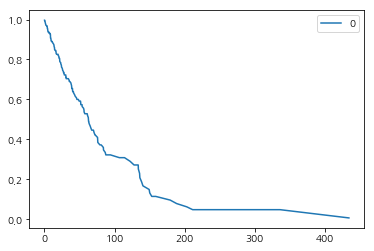

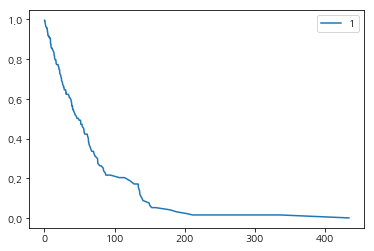

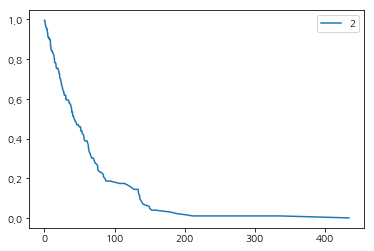

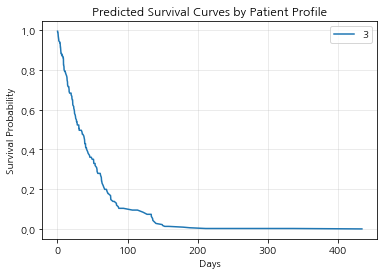


=== 비례위험 가정 검정 ===
           test_statistic         p  -log2(p)
age              0.139990  0.708291  0.497586
gender           0.808677  0.368512  1.440218
stage            0.340984  0.559262  0.838405
treatment        1.306192  0.253085  1.982304


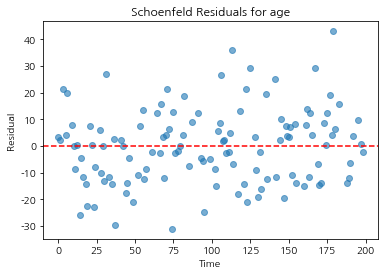

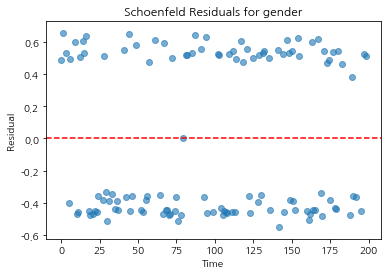

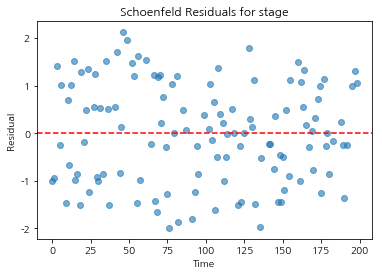

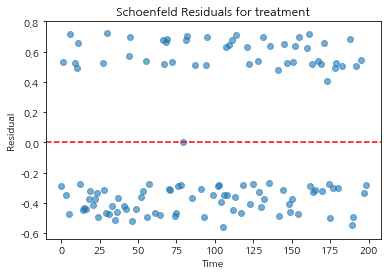


=== 위험비 해석 ===
age: HR = 1.021
  → age 증가 시 위험 2.1% 증가
gender: HR = 1.480
  → gender 증가 시 위험 48.0% 증가
stage: HR = 1.609
  → stage 증가 시 위험 60.9% 증가
treatment: HR = 0.553
  → treatment 증가 시 위험 44.7% 감소

새 환자의 위험 점수: -0.067
6개월 생존 확률: 0.055
1년 생존 확률: 0.010


In [93]:
# Cox 비례위험 모형 (Cox Proportional Hazards Regression) 예제
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sklearn.model_selection import train_test_split

# 1. 데이터 생성 (환자 생존 분석 예제)
np.random.seed(42)
n = 200

# 독립변수
age = np.random.normal(60, 15, n)           # 나이 (평균 60세)
gender = np.random.binomial(1, 0.4, n)     # 성별 (0=남성, 1=여성)
stage = np.random.choice([1,2,3,4], n)     # 암 병기 (1-4단계)
treatment = np.random.binomial(1, 0.5, n)  # 치료법 (0=기존, 1=신규)

# 생존시간과 이벤트 생성 (위험인자에 따라 조정)
hazard_ratio = np.exp(0.02*age + 0.3*gender + 0.4*stage - 0.5*treatment)
survival_time = np.random.exponential(365/hazard_ratio)  # 평균 1년
event = np.random.binomial(1, 0.7, n)  # 70% 이벤트 발생

# 검열 처리 (일부는 관찰 기간 내 이벤트 미발생)
censoring_time = np.random.uniform(30, 1000, n)
observed_time = np.minimum(survival_time, censoring_time)
event = event * (survival_time <= censoring_time)

# 데이터프레임 생성
df = pd.DataFrame({
    'duration': observed_time,
    'event': event,
    'age': age,
    'gender': gender,
    'stage': stage,
    'treatment': treatment
})

print("=== 데이터 요약 ===")
print(df.head())
print(f"\n이벤트 발생률: {df['event'].mean():.3f}")
print(f"평균 관찰기간: {df['duration'].mean():.1f}일")

# 2. Cox 비례위험 모형 적합
cph = CoxPHFitter()
cph.fit(df, duration_col='duration', event_col='event')

# 결과 출력
print("\n=== Cox 회귀 결과 ===")
# 2. Cox 회귀 결과 출력
print(cph.summary)  # .print_summary() 대신 .summary 사용

# 3. 모델 성능 평가
# Concordance Index (C-index): 0.5는 랜덤, 1.0은 완벽한 예측
c_index = cph.concordance_index_
print(f"\nConcordance Index: {c_index:.3f}")

# 4. 생존곡선 예측 및 시각화
# 대표적인 환자 프로필 생성
patient_profiles = pd.DataFrame({
    'age': [50, 70, 50, 70],
    'gender': [0, 0, 1, 1],
    'stage': [2, 3, 2, 3],
    'treatment': [0, 1, 0, 1]
})

plt.figure(figsize=(10, 6))
for i, (idx, patient) in enumerate(patient_profiles.iterrows()):
    survival_func = cph.predict_survival_function(patient.to_frame().T)
    survival_func.plot(label=f'Patient {i+1}: Age{int(patient.age)}, Gender{int(patient.gender)}, Stage{int(patient.stage)}, Treat{int(patient.treatment)}')

plt.title('Predicted Survival Curves by Patient Profile')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. 비례위험 가정 검정
from lifelines.statistics import proportional_hazard_test

# 각 변수별 비례위험 가정 검정
ph_test = proportional_hazard_test(cph, df, time_transform='rank')
print(f"\n=== 비례위험 가정 검정 ===")
print(ph_test.summary)
      
# 6. Schoenfeld 잔차 플롯 (시간-잔차 길이 일치시키기)
schoenfeld = cph.compute_residuals(df, kind='schoenfeld')
# 각 공변량별로, 검열된 시점(잔차 index)별 plot
for covariate in ['age','gender','stage','treatment']:
    if covariate in schoenfeld:
        plt.figure(figsize=(6,4))
        plt.scatter(schoenfeld.index, schoenfeld[covariate], alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f'Schoenfeld Residuals for {covariate}')
        plt.xlabel('Time')
        plt.ylabel('Residual')
        plt.show()

# 7. 위험비(Hazard Ratio) 해석
print("\n=== 위험비 해석 ===")
hazard_ratios = np.exp(cph.params_)
for covariate, hr in hazard_ratios.items():
    print(f"{covariate}: HR = {hr:.3f}")
    if hr > 1:
        print(f"  → {covariate} 증가 시 위험 {(hr-1)*100:.1f}% 증가")
    else:
        print(f"  → {covariate} 증가 시 위험 {(1-hr)*100:.1f}% 감소")

# 8. 예측 및 위험 점수
# 새로운 환자 예측
new_patient = pd.DataFrame({
    'age': [65],
    'gender': [0],
    'stage': [3],
    'treatment': [1]
})

# 위험 점수 (선형 예측자)
risk_score = cph.predict_log_partial_hazard(new_patient)
print(f"\n새 환자의 위험 점수: {risk_score.iloc[0]:.3f}")

# 생존 확률 예측
survival_prob_6m = cph.predict_survival_function(new_patient, times=[180]).iloc[0, 0]
survival_prob_1y = cph.predict_survival_function(new_patient, times=[365]).iloc[0, 0]
print(f"6개월 생존 확률: {survival_prob_6m:.3f}")
print(f"1년 생존 확률: {survival_prob_1y:.3f}")


### ② 와이블 회귀 (Weibull Regression)

- **특징**  
  - 사전 분포 형태를 Weibull 분포로 가정한 생존모형  
  - 파라메트릭: $$ S(t) = \exp[-(t/\lambda)^\kappa] $$

- **전제조건**  
  1. **Weibull 분포 적합성**  
  2. **독립검열**

- **장점**  
  - 파라메트릭 → 예측·해석 용이  
  - 모형 적합도 검사 및 최적화 가능

- **단점**  
  - 분포 가정 위배 시 부정확  
  - 베이스라인 위험함수 유연성 제한

- **사용 예**  
  - 기계 부품 수명 분석  
  - 제품 신뢰성 시험  
  - 임상시험 시간 예측

=== Weibull AFT Regression Results ===
                         coef   exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                     
lambda_ load        -0.004999    0.995013  0.001820       -0.008567   
        temperature -0.004001    0.996007  0.003875       -0.011595   
        Intercept    5.446526  231.950884  0.343443        4.773389   
rho_    Intercept    0.866281    2.378050  0.058679        0.751273   

                     coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
param   covariate                                                               
lambda_ load              -0.001432             0.991470             0.998569   
        temperature        0.003593             0.988472             1.003600   
        Intercept          6.119662           118.319573           454.711011   
rho_    Intercept          0.981289             2.119696             2.667893   

                     cmp to          z         

<Figure size 432x288 with 0 Axes>

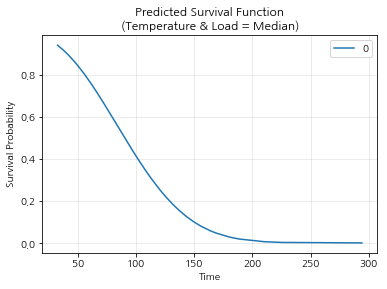

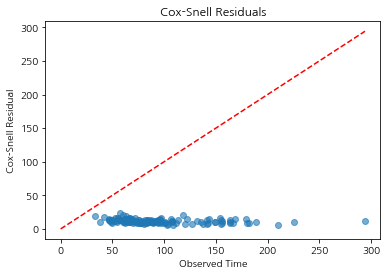

In [94]:
# 와이블 회귀 (Weibull AFT) 예제

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

# 1. 데이터 생성 (기계 부품 신뢰성 분석)
np.random.seed(0)
n = 200

# 공변량: 사용 온도(temperature), 하중(load)
temperature = np.random.normal(75, 10, n)    # 평균 75℃, 표준편차 10
load        = np.random.normal(100, 20, n)   # 평균 100N, 표준편차 20

# 기본 수명 분포 파라미터
baseline_lambda = 500  # 스케일 파라미터
baseline_rho    = 1.5  # 형태 파라미터

# AFT 모형 선형 예측자(로그-생존시간의 평균)
#   log(T) = β₀ + β₁*temperature + β₂*load + σ·ε, ε ~ EV(0,1)
beta_0 = 5.5
beta_1 = -0.01   # 온도 상승 → 수명 단축
beta_2 = -0.005  # 하중 상승 → 수명 단축
sigma  = 0.3     # 분산 조절

# 로그-수명 생성
log_life = (beta_0
            + beta_1 * temperature
            + beta_2 * load
            + sigma * np.random.gumbel(size=n))

# 실제 수명과 검열
life_time = np.exp(log_life)
censor_time = np.random.uniform(100, 2000, n)
observed_time = np.minimum(life_time, censor_time)
event_observed = (life_time <= censor_time).astype(int)

# 데이터프레임 준비
df = pd.DataFrame({
    'T': observed_time,
    'E': event_observed,
    'temperature': temperature,
    'load': load
})

# 2. 데이터 분할
train_df, test_df = train_test_split(df, test_size=0.3, random_state=1)

# 3. 와이블 AFT 모형 적합
aft = WeibullAFTFitter()
aft.fit(train_df, duration_col='T', event_col='E')

# 4. 모형 요약
print("=== Weibull AFT Regression Results ===")
print(aft.summary)

# 5. 예측 성능 (Concordance Index)
c_index_train = aft.concordance_index_
c_index_test  = concordance_index(test_df['T'], -aft.predict_median(test_df), test_df['E'])
print(f"\nConcordance Index (train): {c_index_train:.3f}")
print(f"Concordance Index (test) : {c_index_test:.3f}")

# 6. 생존함수 예측 및 시각화
# 평균 수준의 공변량 설정 
median_temp = df['temperature'].median()
median_load = df['load'].median()
profile = pd.DataFrame({
    'temperature': [median_temp],
    'load': [median_load]
})

surv_func = aft.predict_survival_function(profile)
plt.figure(figsize=(6,4))
surv_func.plot()
plt.title('Predicted Survival Function\n(Temperature & Load = Median)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.show()

# 7. 로그-수명 잔차 (Cox-Snell Residuals) 검사
# Cox-Snell 잔차: -log(Survival)
cs_resid = -np.log(aft.predict_survival_function(train_df).iloc[-1])
plt.figure(figsize=(6,4))
plt.scatter(train_df['T'], cs_resid, alpha=0.6)
plt.plot([0, np.max(train_df['T'])], [0, np.max(train_df['T'])], 'r--')
plt.title('Cox-Snell Residuals')
plt.xlabel('Observed Time')
plt.ylabel('Cox-Snell Residual')
plt.show()


## 3-3. 분위수 회귀 (Quantile Regression)

- **특징**  
  - 종속변수의 **특정 분위수(quantile)**를 예측  
  - 중위값(0.5분위), 상하위 분위수 모두 모델링

- **전제조건**  
  - 선형관계 가정(분위수별)  
  - 잔차 독립성(분위수별)

- **장점**  
  - 분포 전체 예측(중위·극단 추정)  
  - 이상치에 강건  
  - 등분산성 가정 불필요

- **단점**  
  - 계산 비용 상승(여러 분위수 반복 추정)  
  - 해석 복잡(분위수별 계수 차이)

- **사용 예**  
  - 주택 가격 분포(상·하위권 예측)  
  - 임금 분포 분석(저임금층 예측)  
  - 금융 손실(Value-at-Risk) 예측`

Quantile = 0.25
                          QuantReg Regression Results                          
Dep. Variable:                foodexp   Pseudo R-squared:               0.5540
Model:                       QuantReg   Bandwidth:                       62.66
Method:                 Least Squares   Sparsity:                        256.2
Date:                Mon, 25 Aug 2025   No. Observations:                  235
Time:                        03:26:15   Df Residuals:                      233
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.4835     18.471      5.169      0.000      59.092     131.875
income         0.4741      0.017     27.310      0.000       0.440       0.508

The condition number is large, 2.38e+03. This might indicate that there are
strong multicollinearity or other num

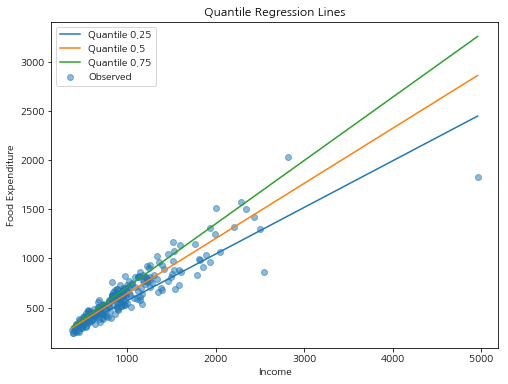

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg

# 1. 데이터 로드: Engel 데이터셋 (가계 소득 대비 식품 지출)
data = sm.datasets.engel.load_pandas().data
# 'income'을 설명 변수, 'foodexp'를 종속 변수로 사용
X = data['income']
y = data['foodexp']

# 절편(intercept) 컬럼 추가
X = sm.add_constant(X)

# 2. 분위수 회귀 모델 적합
quantiles = [0.25, 0.5, 0.75]
models = {}
results = {}

for q in quantiles:
    # Quantile Regression 모델 정의
    mod = QuantReg(y, X)
    # 적합: q 분위수
    res = mod.fit(q=q)
    models[q] = mod
    results[q] = res
    print(f"Quantile = {q}\n", res.summary(), "\n")

# 3. 회귀선 시각화
plt.figure(figsize=(8,6))
# 산점도
plt.scatter(data['income'], data['foodexp'], alpha=0.5, label='Observed')

# 분위수별 회귀선
incomes = np.linspace(data['income'].min(), data['income'].max(), 100)
X_pred = sm.add_constant(incomes)
for q in quantiles:
    y_pred = results[q].predict(X_pred)
    plt.plot(incomes, y_pred, label=f'Quantile {q}')

plt.xlabel('Income')
plt.ylabel('Food Expenditure')
plt.title('Quantile Regression Lines')
plt.legend()
plt.show()


# 4. 고급 회귀 기법

일반 회귀를 넘어 **과적합 방지**, **변수 선택**, **이상치 강건성** 등을 강화한 기법들이다. 각 기법의 특징, 전제조건, 장·단점, 사용 예시를 정리하였다.

***

## **요약 비교표**

| 기법                  | 목적            | 전제조건             | 장점                         | 단점                           |
|---------------------|---------------|---------------------|----------------------------|------------------------------|
| Ridge               | 과적합 방지      | OLS + λ 최적화      | 다중공선성 완화, 예측 안정    | 변수 선택 불가                  |
| Lasso               | 특성 선택       | OLS + λ 최적화      | 자동 변수 선택, 과적합 방지   | λ 민감, 상관변수 처리 이슈        |
| Elastic Net         | 선택+안정화     | OLS + α,λ 최적화    | 그룹 변수 선택, 안정적 예측   | 하이퍼파라미터 튜닝 복잡, 비용 증가 |
| Forward Selection   | 변수 자동 추가   | OLS + 후보 변수     | 계산 효율, 해석성 유지        | 제거 불가, 초기 민감              |
| Backward Elimination | 변수 자동 제거   | OLS + 충분 변수 수  | 최종 모델 간결                | 계산 비용 높음, 상호작용 미고려   |
| Stepwise Regression | 추가/제거 결합    | OLS + 변수 후보     | 유연한 선택, 균형 모델         | 계산 비용 증가, 기준 민감          |
| Huber Regression    | 이상치 강건성    | 선형성+독립성       | 이상치 영향 완화, 효율적       | δ 설정 민감, 극단 이상치 처리 한계 |
| Jackknife Regression| 편향·분산 추정   | 독립 관측치         | 편향 보정, 신뢰구간 추정       | 계산 비용 매우 높음               |


## 4-2. 단계적 회귀 (Stepwise Regression)

자동으로 변수 선택·제거를 수행하여 모델 단순화.

### ① Forward Selection

- **특징**  
  - 빈 모델에서 시작해 유의미한 변수부터 순차 추가  
  - 추가 시 AIC/BIC/p-값 기준 사용

- **전제조건**  
  - OLS 전제조건  
  - 변수 후보 사전 정의

- **장점**  
  - 계산 효율적(변수 추가만)  
  - 과적합 방지, 해석성 유지

- **단점**  
  - 추가된 변수 제거 불가  
  - 초기 모델 민감

- **사용 예**  
  - 변수 후보 많으나 적은 수만 선택할 때  
  - 해석 중심 모델링

### ② Backward Elimination

- **특징**  
  - 전체 변수 포함 모델에서 시작해 비유의미 변수 순차 제거  
  - 제거 시 AIC/BIC/p-값 기준 사용

- **전제조건**  
  - OLS 전제조건  
  - 충분한 초기 변수 수

- **장점**  
  - 전체 변수 고려 후 제거  
  - 최종 모델 간결

- **단점**  
  - 계산 비용 높음(초기 모델 복잡)  
  - 상호작용 고려 어려움

- **사용 예**  
  - 변수 수 중간 이하일 때  
  - 모든 변수 잠재적 중요도 높을 때

### ③ Stepwise Regression (Forward + Backward)

- **특징**  
  - Forward와 Backward를 교차 수행해 변수 추가·제거  
  - 유연한 변수 선택

- **장점**  
  - 지역 최적해 회피 가능  
  - 모델 단순화와 성능 균형

- **단점**  
  - 계산 비용 증가  
  - 기준(p-값 등) 선택 민감

- **사용 예**  
  - 해석성과 예측력 모두 필요한 실무

## 4-3. 로버스트 회귀 (Robust Regression)

이상치의 영향을 줄여 안정적 추정.

### ① Huber Regression

- **특징**  
  - 오차에 대한 손실함수 변경:  
    - 잔차 작을 때 제곱손실, 잔차 클 때 절댓값 손실  
  - 이상치 완만하게 페널티

- **전제조건**  
  - 선형 회귀 기본 가정(잔차 불필요한 정규성 엄격성 완화)  
  - 임계값 δ 설정

- **장점**  
  - 이상치 영향 완화  
  - 계산 효율적(Convex 최적화)

- **단점**  
  - δ 민감성  
  - 극단 이상치 처리 한계

- **사용 예**  
  - 노이즈 많거나 이상치 존재 데이터  
  - 센서 오차 모델링

### ② Jackknife Regression

- **특징**  
  - 관측치 하나씩 제거하며 추정치 반복 계산  
  - **편향(bias)** 및 **분산(variance)** 추정

- **전제조건**  
  - 선형 회귀 기본 가정  
  - 독립 관측치

- **장점**  
  - 작은 표본에서 편향 보정 가능  
  - 불확실성 추정

- **단점**  
  - 계산 비용 매우 높음 (n회 모형 적합)  
  - 이상치 완전 제거는 아님

- **사용 예**  
  - 소규모 데이터의 신뢰구간 추정  
  - 모델 안정성 평가

Huber MSE: 3.082
OLS   MSE: 3.032


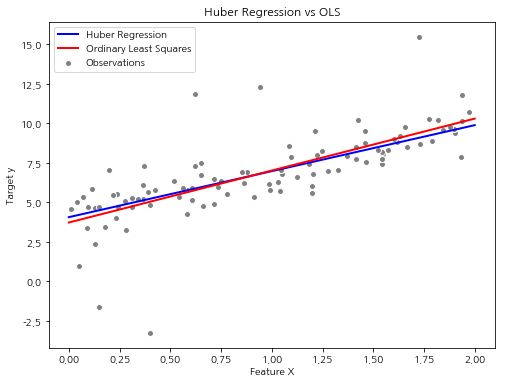

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 인공 데이터 생성
np.random.seed(42)
n_samples = 100
X = 2 * np.random.rand(n_samples, 1)
y = 4 + 3 * X.ravel() + np.random.randn(n_samples)  # y = 4 + 3x + noise

# 이상치 추가
n_outliers = 10
indices = np.random.choice(np.arange(n_samples), n_outliers, replace=False)
y[indices] += 15 * (np.random.rand(n_outliers) - 0.5)  # 큰 변동 추가

# 2. 모델 정의 및 학습
huber = HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=100)
ols = LinearRegression()

huber.fit(X, y)
ols.fit(X, y)

# 3. 예측 및 평가
X_test = np.linspace(0, 2, 100).reshape(-1, 1)
y_pred_huber = huber.predict(X_test)
y_pred_ols   = ols.predict(X_test)

mse_huber = mean_squared_error(y, huber.predict(X))
mse_ols   = mean_squared_error(y, ols.predict(X))
print(f"Huber MSE: {mse_huber:.3f}")
print(f"OLS   MSE: {mse_ols:.3f}")

# 4. 결과 시각화
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='gray', edgecolor='white', label='Observations')
plt.plot(X_test, y_pred_huber, color='blue', linewidth=2, label='Huber Regression')
plt.plot(X_test, y_pred_ols,   color='red',  linewidth=2, label='Ordinary Least Squares')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Huber Regression vs OLS')
plt.legend()
plt.show()


In [107]:
import numpy as np
import statsmodels.api as sm

# 1. 인공 데이터 생성
np.random.seed(42)
n = 50
X = np.random.uniform(0, 10, size=n)
# 실제 모형: y = 2.5 + 1.8 * X + noise
y = 2.5 + 1.8 * X + np.random.normal(scale=2.0, size=n)

# 절편 포함
X_design = sm.add_constant(X)

# 2. 전체 데이터로 회귀 적합
model_full = sm.OLS(y, X_design)
result_full = model_full.fit()
beta_full = result_full.params  # [intercept, slope]

print("Full-sample coefficients:")
print("Intercept =", beta_full[0])
print("Slope     =", beta_full[1])

# 3. Jackknife 수행: leave-one-out 회귀
jack_coefs = np.zeros((n, 2))  # 각 샘플 제외 시 intercept, slope 저장

for i in range(n):
    # 관측치 i 제외
    mask = np.arange(n) != i
    Xi = X_design[mask]
    yi = y[mask]
    
    # 회귀 적합
    model_i = sm.OLS(yi, Xi)
    res_i = model_i.fit()
    jack_coefs[i] = res_i.params

# 4. Jackknife 추정량 계산
# 평균 계수
beta_jack_mean = jack_coefs.mean(axis=0)

# 편향(bias) = (n - 1) * (beta_jack_mean - beta_full)
bias = (n - 1) * (beta_jack_mean - beta_full)

# 표준 오차(se) = sqrt[ (n - 1) / n * sum_i (beta_i - beta_jack_mean)^2 ]
se = np.sqrt((n - 1) / n * np.sum((jack_coefs - beta_jack_mean)**2, axis=0))

print("\nJackknife estimates:")
print("Mean intercept =", beta_jack_mean[0])
print("Mean slope     =", beta_jack_mean[1])

print("\nBias corrections:")
print("Intercept bias =", bias[0])
print("Slope bias     =", bias[1])

print("\nStandard errors:")
print("SE(intercept) =", se[0])
print("SE(slope)     =", se[1])


Full-sample coefficients:
Intercept = 2.6933785489377757
Slope     = 1.7553132007706198

Jackknife estimates:
Mean intercept = 2.693296536748479
Mean slope     = 1.7553338174538475

Bias corrections:
Intercept bias = -0.004018597275533331
Slope bias     = 0.0010102174781585482

Standard errors:
SE(intercept) = 0.49238623558742617
SE(slope)     = 0.11069912987598544
